# -- Notebook 02: Analysis --

**Summary of the notebook:**

* Evaluating different models on their ability to predict collision_severity 
    * We look at a simple OLS regression, a LASSO model, and a gradient-boosted decision tree
* Examining which ex-ante variable best predicts collision severity 


In [21]:
# Necessary libraries: 

import pandas as pd 
import numpy as np 
import matplotlib as plt 

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import xgboost

from sklearn.ensemble import HistGradientBoostingClassifier



In [2]:
# Importing datasets: 

train_df = pd.read_csv('C:/Users/abhik/OneDrive/Desktop/WISE/Data/Processed/train_df.csv')
test_df= pd.read_csv('C:/Users/abhik/OneDrive/Desktop/WISE/Data/Processed/test_df.csv')

In [3]:
# Specifying predictor variables: 

predictors = ['location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 
              'day_of_week', 'time', 'local_authority_district','first_road_class', 
              'road_type', 'speed_limit','vehicle_type', 'vehicle_left_hand_drive' , 
              'sex_of_driver', 'age_of_driver', 'driver_imd_decile' , 'engine_capacity_cc', 
              'propulsion_code', 'age_of_vehicle' , 'generic_make_model', 'lsoa_of_driver',
              'journey_purpose_of_driver_historic' , 'age_of_casualty', 'sex_of_casualty', 
              'casualty_type']

In [4]:
# Splitting the test/train data into the predictors and outcome: 

X_train = train_df[predictors]
y_train = train_df[['collision_severity']]

X_test = test_df[predictors]
y_test = test_df[['collision_severity']]

In [5]:
# Scaling/normalising the predictors: 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
     X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled, columns=X_test.columns, index=X_test.index
)


In [6]:
# Adjusting values of collision_severity: 

y_train = y_train - 1
y_test = y_test - 1

**OLS Regression:**

In [7]:
# Creating the model: 
ols = LinearRegression()

# Fitting model on training data: 
ols.fit(X_train_scaled_df, y_train)

# Generating predictions on test_data: 
y_pred_ols = ols.predict(X_test_scaled_df)

*Evaluating model performance:*

In [8]:
# Using Out-Of-Sample R^2: 

def oos_r2(y_true, y_pred, y_train_mean): 
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_train_mean)**2)
    
    return 1 - ss_res/ ss_tot

train_mean = y_train.mean().item()

# Calculating OOS R^2 for OLS: 

r2_ols = oos_r2(y_test.values, y_pred_ols, train_mean)
print(r2_ols)

0.05173445981693214


In [9]:
# Using MSE: 

from sklearn.metrics import mean_squared_error

# Calculate MSE
mse_ols = mean_squared_error(y_test.values, y_pred_ols)
print(mse_ols)

0.23389958246336415


**LASSO Regression:**

In [10]:
lasso = Lasso(alpha = 5)
lasso.fit(X_train_scaled_df, y_train)
train_score_lasso = lasso.score(X_train_scaled_df, y_train)
test_score_ls = lasso.score(X_test_scaled_df, y_test)

print(test_score_ls)


-0.0029135528808246214


<Axes: >

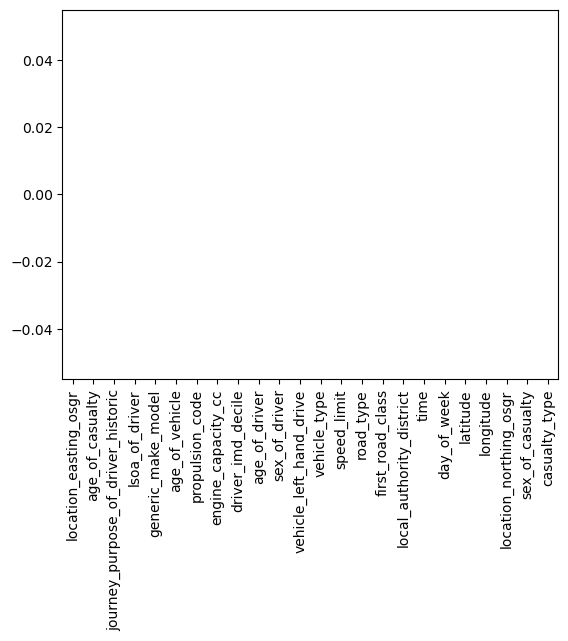

In [11]:
pd.Series(lasso.coef_, X_train_scaled_df.columns).sort_values(ascending = True).plot(kind = 'bar')

Here, we see that setting the penalty to an arbitrary number that is too high can result in the LASSO model setting all coefficients to 0. 

In [12]:
# Selecting optimal penalty using cross-validation: 

lasso_cv = LassoCV(alphas = [0.0001, 0.001,0.01, 0.1, 1, 10], random_state=0).fit(X_train_scaled_df, y_train)


c:\Users\abhik\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1623: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\abhik\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 16902.071517476506, tolerance: 18.14530178491472
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\abhik\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18123.8603386857, tolerance: 18.12412745443465
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\abhik\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Ob

In [13]:
print(lasso_cv.score(X_test_scaled_df, y_test))

0.047452012726748816


<Axes: >

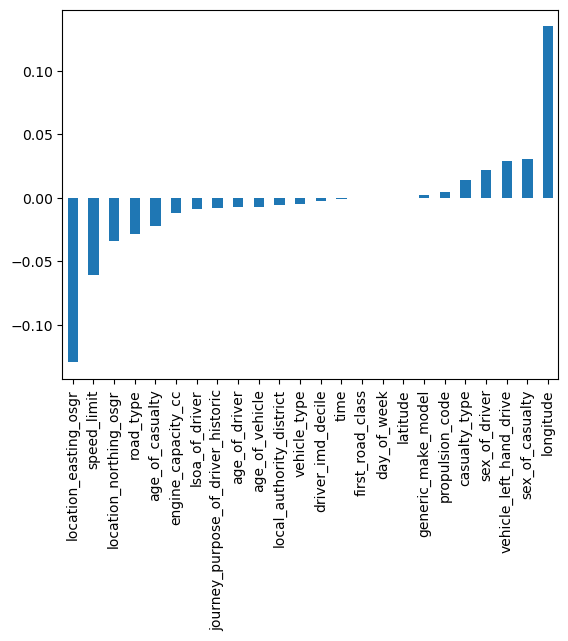

In [14]:
pd.Series(lasso_cv.coef_, X_train_scaled_df.columns).sort_values(ascending = True).plot(kind = 'bar')

**Gradient-Boosted Decision Tree**

In [ ]:

# Create the model
gradtree = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=100,      # Equivalent to n_estimators in GradientBoostingClassifier
    max_depth=3,
    random_state=42
)

# Train the model
gradtree.fit(X_train, y_train['collision_severity'])

# Make predictions
y_pred = gradtree.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test['collision_severity'], y_pred))

print("\nClassification Report:")
print(classification_report(y_test['collision_severity'], y_pred))


Accuracy: 0.7387066164419013

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.02      0.04      4985
           1       0.54      0.07      0.12     60102
           2       0.75      0.98      0.85    178352

    accuracy                           0.74    243439
   macro avg       0.57      0.36      0.34    243439
weighted avg       0.69      0.74      0.65    243439



In [31]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "max_iter": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_search = GridSearchCV(
    estimator=gradtree,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1      # Uses all CPU cores
)

# Fit
grid_search.fit(X_train, y_train['collision_severity'])

# Results
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200}
Best CV accuracy: 0.7682717558094535


In [32]:
# Model with updated parameters: 
gradtree = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,      # Equivalent to n_estimators in GradientBoostingClassifier
    max_depth=5,
    random_state=42
)

# Train the model
gradtree.fit(X_train, y_train['collision_severity'])

# Make predictions
y_pred = gradtree.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test['collision_severity'], y_pred))

print("\nClassification Report:")
print(classification_report(y_test['collision_severity'], y_pred))

Accuracy: 0.7396390882315488

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.03      0.05      4985
           1       0.53      0.10      0.17     60102
           2       0.75      0.98      0.85    178352

    accuracy                           0.74    243439
   macro avg       0.52      0.37      0.35    243439
weighted avg       0.69      0.74      0.66    243439



In [34]:
from sklearn.inspection import permutation_importance

<Axes: title={'center': 'Variable Importance Plot'}, xlabel='Importance', ylabel='Variables'>

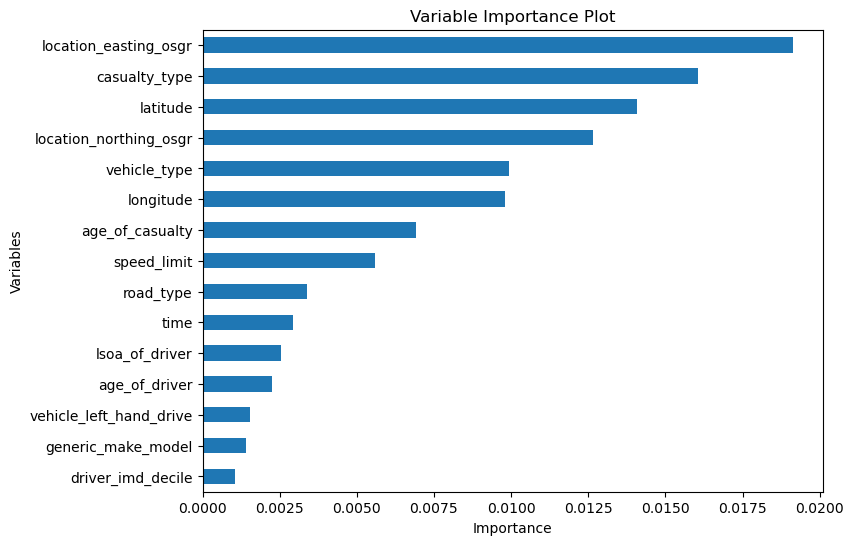

In [ ]:
# Using a smaller sample of test data for faster calculation
X_test_sample = X_test.sample(
    n=min(5000, len(X_test)), 
    random_state=42
)

y_test_sample = y_test.loc[X_test_sample.index, 'collision_severity']

result = permutation_importance(
    gradtree,
    X_test_sample,
    y_test_sample,
    n_repeats=3,      
    random_state=42,
    n_jobs=-1          
)

importance = pd.Series(
    result.importances_mean,
    index=X_train.columns
).sort_values()

# Plotting top 15 features
importance.tail(15).plot.barh(figsize=(8,6), title = "Variable Importance Plot", xlabel = "Importance", ylabel = "Variables")


The above plot shows us how much each variable contributed to the prediction of the outcome (collision severity). This shows us that variables like location, type of casualty, and type of vehicle are the strongest predictors of how severe the collision will be, with other variables like speed limit, age of casualty, and road type also playing a moderate influence. 